<a href="https://colab.research.google.com/github/dheep2305-git/Tsf-tasks/blob/main/Tsf_task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

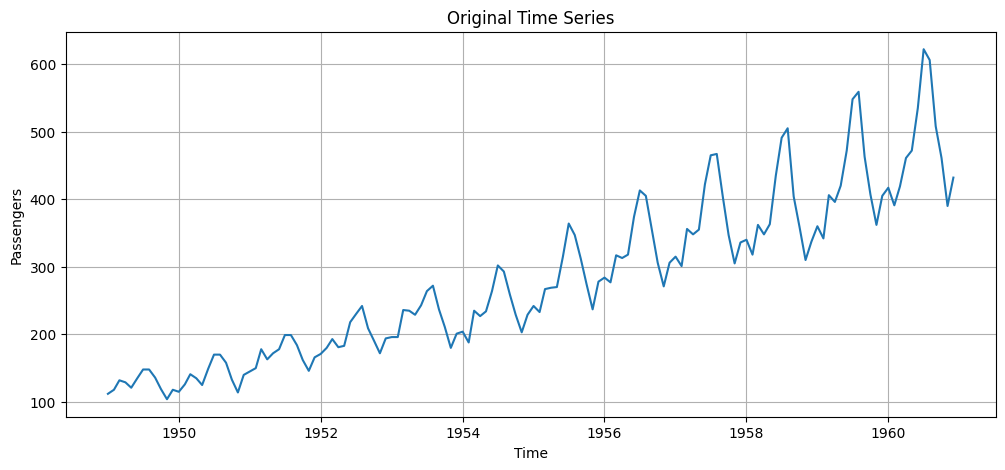

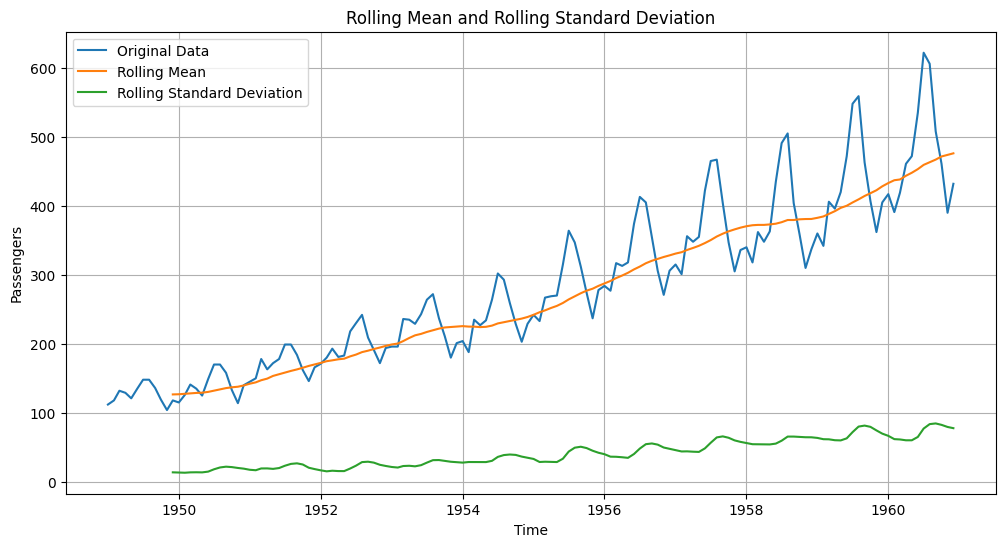

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598

Conclusion: Data is Non-Stationary


In [1]:
# TASK 4: STATIONARITY TEST

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.datasets import get_rdataset
from statsmodels.tsa.stattools import adfuller

# Step 2: Load AirPassengers dataset
data = get_rdataset("AirPassengers", "datasets").data

# Step 3: Prepare time-series data
data['time'] = pd.date_range(start='1949-01-01',
                             periods=len(data),
                             freq='MS')

data.set_index('time', inplace=True)

# Rename column
data.rename(columns={'value': 'Passengers'}, inplace=True)

# Create time series
ts = data['Passengers']

# Step 4: Plot original time series
plt.figure(figsize=(12, 5))

plt.plot(ts)

plt.title('Original Time Series')
plt.xlabel('Time')
plt.ylabel('Passengers')

plt.grid()
plt.show()

# Step 5: Calculate rolling mean
rolling_mean = ts.rolling(window=12).mean()

# Step 6: Calculate rolling standard deviation
rolling_std = ts.rolling(window=12).std()

# Step 7: Plot original data and rolling statistics
plt.figure(figsize=(12, 6))

plt.plot(ts,
         label='Original Data')

plt.plot(rolling_mean,
         label='Rolling Mean')

plt.plot(rolling_std,
         label='Rolling Standard Deviation')

plt.title('Rolling Mean and Rolling Standard Deviation')

plt.xlabel('Time')
plt.ylabel('Passengers')

plt.legend()
plt.grid()

plt.show()

# Step 8: Perform Augmented Dickey-Fuller Test
adf_result = adfuller(ts.dropna())

# Step 9: Display ADF results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

# Step 10: Check stationarity
alpha = 0.05

if adf_result[1] <= alpha:
    print("\nConclusion: Data is Stationary")
else:
    print("\nConclusion: Data is Non-Stationary")